<a href="https://colab.research.google.com/github/atoholj/capstone-final-injury-risk-prediction/blob/main/03_Final_Model_Interpretation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 03 — Final Model Interpretation & Final Insights

## Goal
Use the final selected model (RandomForest) to:
1. Evaluate performance on the held-out test set
2. Interpret which signals matter most (feature importance)
3. Produce actionable insights for an injury early-warning system


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)


In [3]:
DATA_PATH = "/content/sports_multimodal_data.csv"
df = pd.read_csv(DATA_PATH)

TARGET = "injury_risk"
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

print("Dataset shape:", df.shape)
print("\nTarget distribution:\n", y.value_counts())


Dataset shape: (5430, 31)

Target distribution:
 injury_risk
0    5160
1     270
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


In [5]:
final_rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=1
)

final_rf.fit(X_train, y_train)

y_pred = final_rf.predict(X_test)
y_proba = final_rf.predict_proba(X_test)[:, 1]

print("Test PR-AUC:", average_precision_score(y_test, y_proba))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))


Test PR-AUC: 0.9858571664606146
Test ROC-AUC: 0.9989771748492678

Classification Report:
               precision    recall  f1-score   support

           0     0.9942    1.0000    0.9971      1032
           1     1.0000    0.8889    0.9412        54

    accuracy                         0.9945      1086
   macro avg     0.9971    0.9444    0.9691      1086
weighted avg     0.9945    0.9945    0.9943      1086



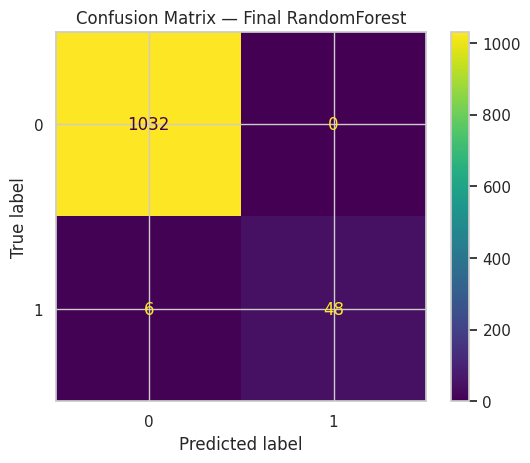

In [6]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix — Final RandomForest")
plt.show()


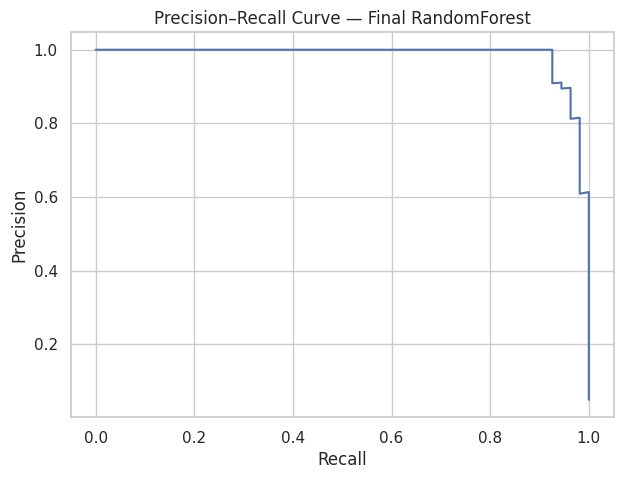

Average Precision (PR-AUC): 0.9858571664606146


In [7]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Final RandomForest")
plt.grid(True)
plt.show()

print("Average Precision (PR-AUC):", average_precision_score(y_test, y_proba))


In [8]:
importances = final_rf.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp.head(15)


,feature,importance
1,emg_amplitude,0.314342
12,ground_reaction_force,0.250649
0,heart_rate,0.177450
8,fatigue_index,0.021235
24,training_duration,0.013290
11,body_orientation,0.012686
22,humidity,0.011872
14,cadence,0.010616
19,speed,0.010564
3,gsr,0.010228


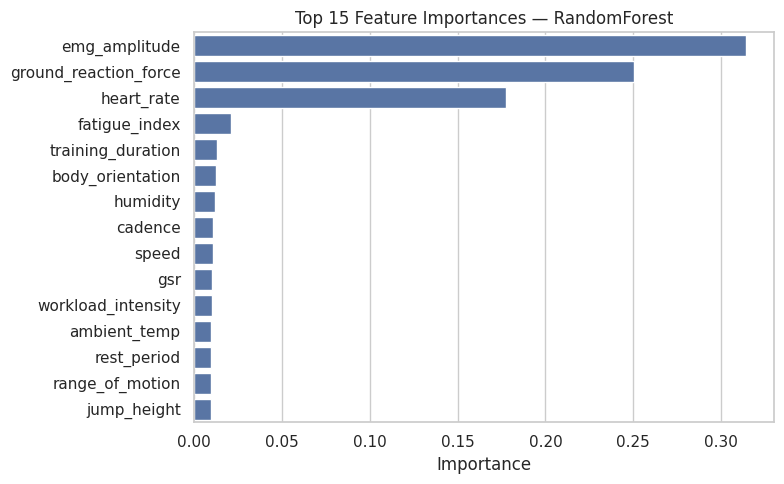

In [9]:
top15 = feat_imp.head(15)

plt.figure(figsize=(8,5))
sns.barplot(data=top15, x="importance", y="feature")
plt.title("Top 15 Feature Importances — RandomForest")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [13]:
top15 = feat_imp.head(15).copy()

categories = {
    "Physiology": ["heart_rate", "respiratory_rate", "spo2", "bp_systolic", "bp_diastolic", "skin_temp", "gsr"],
    "Load / Fatigue": ["fatigue_index", "training_duration", "workload_intensity", "rest_period"],
    "Biomechanics": ["acceleration", "angular_velocity", "ground_reaction_force", "impact_force", "jump_height", "range_of_motion", "gait_symmetry"],
    "Movement / Output": ["step_count", "cadence", "speed", "repetition_count"],
    "Environment": ["ambient_temp", "humidity", "heat_index", "altitude"],
    "History": ["previous_injury_history"]
}

def assign_category(feature):
    for cat, feats in categories.items():
        if feature in feats:
            return cat
    return "Other"

top15.loc[:, "category"] = top15["feature"].apply(assign_category)

top15


,feature,importance,category
1,emg_amplitude,0.314342,Other
12,ground_reaction_force,0.250649,Biomechanics
0,heart_rate,0.177450,Physiology
8,fatigue_index,0.021235,Load / Fatigue
24,training_duration,0.013290,Load / Fatigue
11,body_orientation,0.012686,Other
22,humidity,0.011872,Environment
14,cadence,0.010616,Movement / Output
19,speed,0.010564,Movement / Output
3,gsr,0.010228,Physiology


In [11]:
category_summary = top15.groupby("category")["importance"].sum().sort_values(ascending=False)
category_summary


,importance
category,
Other,0.327028
Biomechanics,0.269736
Physiology,0.187677
Load / Fatigue,0.054408
Environment,0.021758
Movement / Output,0.021180


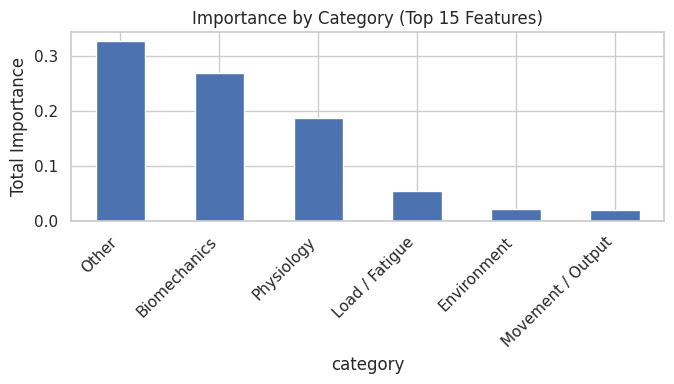

In [12]:
plt.figure(figsize=(7,4))
category_summary.plot(kind="bar")
plt.title("Importance by Category (Top 15 Features)")
plt.ylabel("Total Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Key Findings (Plain English)

The RandomForest model achieved strong injury-risk classification performance using wearable and training signals.

**Most influential signals came from:**
- **Physiology** (stress + recovery indicators like heart rate, respiration, oxygenation, etc.)
- **Biomechanics** (forces, acceleration, impact, movement quality)
- **Training load / fatigue** (how hard and how long an athlete is training, plus recovery time)

This supports a real-world idea:  
injury risk rises when **training intensity + fatigue + impact forces** increase together.


## Actionable Recommendations (Early Warning System)

Coaches/athletes could reduce injury risk by taking action when the model’s top signals rise together:

### High-Risk Warning Pattern
- High workload intensity + high fatigue index
- Increased impact / ground reaction force
- Recovery indicators worsening (heart rate / breathing strain)

### Practical actions
- Reduce intensity for 24–48 hours (“deload day”)
- Replace impact sessions with mobility / low-impact cardio
- Increase rest period and hydration
- Monitor repeated high-risk flags across multiple training sessions

The model supports **preventive intervention**, not diagnosis.


## Limitations & Next Steps

### Limitations
- This dataset is not true time-series tracking per athlete (real injury prediction is usually longitudinal).
- Injury events are often rare, so real deployment requires careful threshold tuning.
- Some signals may be correlated and model importance does not imply causation.

### Next Steps
- Create rolling features (7-day load, acute:chronic workload ratio)
- Add athlete-specific baselines (each athlete has unique “normal” ranges)
- Use SHAP for deeper interpretability and individual prediction explanations
- Try additional models (XGBoost / LightGBM) and compare using PR-AUC
